# Conformation distance evaluation demo

This notebook reproduces the lightweight conformation-distance visualization used for the RMMol examples. It compares pairwise embedding distances with RDKit USR conformational distances on a common LNPDB ionizable-lipid pair set.

The packaged CSV is a deterministic sample from the full 10k-pair evaluation. Use the same plotting function with your own full `*_pair_distances.csv` files to regenerate manuscript-scale panels.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from sklearn.preprocessing import MinMaxScaler

DATA_DIR = Path('data')
summary = pd.read_csv(DATA_DIR / 'conformation_distance_lnpdb_common10k_summary.csv')
pairs = pd.read_csv(DATA_DIR / 'conformation_distance_lnpdb_common10k_pair_sample.csv')
summary[['model_label', 'common_molecules', 'valid_points', 'spearman_r', 'pearson_r']].sort_values('spearman_r', ascending=False)

,model_label,common_molecules,valid_points,spearman_r,pearson_r
1,RMMol,1067,10000,0.855346,0.917257
2,UniMol,1067,10000,0.841888,0.854425
0,ConfSeq,1067,10000,0.640306,0.637884
3,MoLFormer,1067,10000,0.554527,0.516348
5,FCFP,1067,10000,0.479640,0.386122
4,MoleBERT,1067,10000,0.443749,0.362809


In [4]:
def plot_activity_cliff_log_transform(layer2_dist_cliff, conf_dist_cliff, model_label='RMMol', ax=None):
    mask = ~np.isnan(layer2_dist_cliff) & ~np.isnan(conf_dist_cliff)
    embed_clean = layer2_dist_cliff[mask]
    conf_clean = conf_dist_cliff[mask]
    if len(embed_clean) < 10:
        raise ValueError('Too few valid points for a meaningful plot.')

    rho, rho_p = spearmanr(embed_clean, conf_clean)
    pear, pear_p = pearsonr(embed_clean, conf_clean)

    embed_log = np.log1p(embed_clean)
    conf_log = np.log1p(conf_clean)

    scaler = MinMaxScaler()
    embed_norm = scaler.fit_transform(embed_log.reshape(-1, 1)).flatten()
    conf_norm = scaler.fit_transform(conf_log.reshape(-1, 1)).flatten()

    if ax is None:
        _, ax = plt.subplots(figsize=(4.2, 3.8))
    hb = ax.hexbin(embed_norm, conf_norm, gridsize=32, cmap='plasma', bins='log', mincnt=1, alpha=0.82)
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.35, linewidth=1)
    z = np.polyfit(embed_norm, conf_norm, 1)
    x_line = np.linspace(0, 1, 100)
    ax.plot(x_line, np.poly1d(z)(x_line), color='#b2182b', linewidth=1.6)
    ax.set_xlabel('Embedding distance')
    ax.set_ylabel('Conformational distance')
    ax.set_title(f'{model_label}: Spearman={rho:.3f}, Pearson={pear:.3f}', fontsize=9)
    return hb, {'spearman_r': rho, 'spearman_p': rho_p, 'pearson_r': pear, 'pearson_p': pear_p, 'slope': z[0]}

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 0.8,
    'font.size': 8,
    'figure.dpi': 160,
})

,spearman_r,spearman_p,pearson_r,pearson_p,slope
model,,,,,
RMMol,0.864293,1.283656e-180,0.921652,4.799555e-248,0.975140
UniMol,0.850715,3.539206e-169,0.856596,5.479847e-174,0.897001
ConfSeq,0.672961,2.355953e-80,0.654771,9.842534e-75,0.788540
MoLFormer,0.560208,7.177096e-51,0.533865,1.657644e-45,0.809897
FCFP,0.478815,1.036681e-35,0.374396,2.112294e-21,0.789104
MoleBERT,0.440604,6.907306e-30,0.340338,9.779285e-18,0.555032


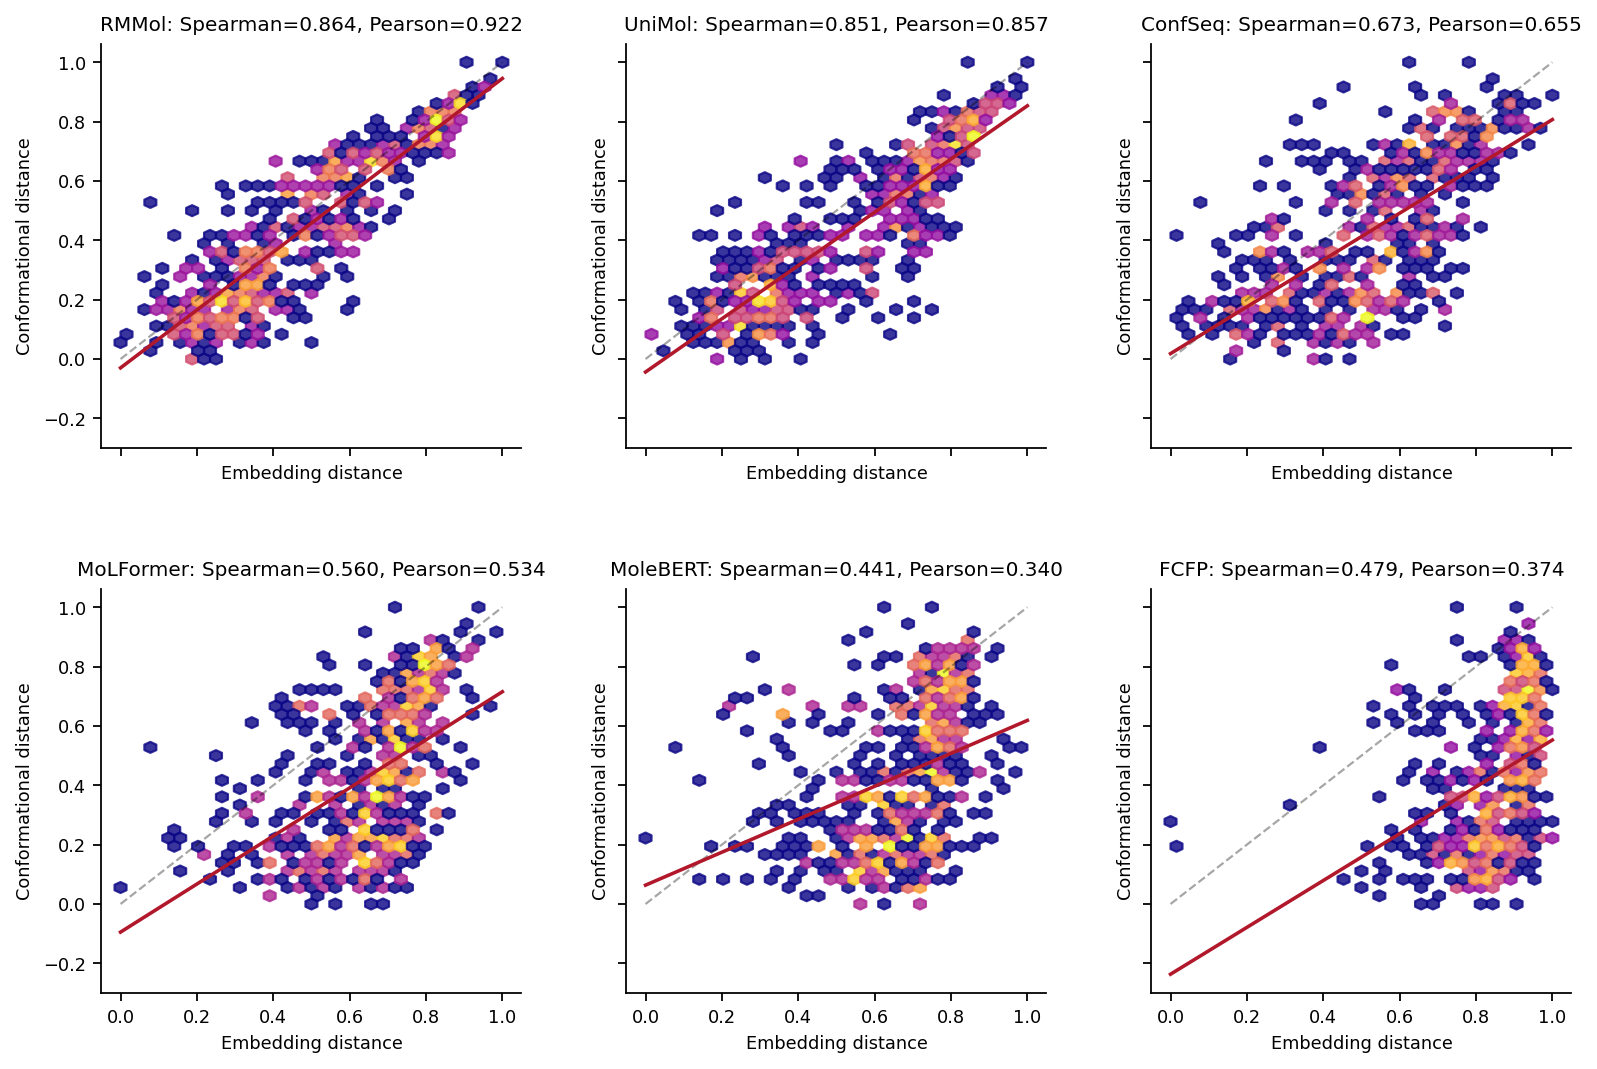

In [10]:
models = ['RMMol', 'UniMol', 'ConfSeq', 'MoLFormer', 'MoleBERT', 'FCFP']
fig, axes = plt.subplots(2, 3, figsize=(12.5, 7.7), sharex=True, sharey=True)
stats = []
last_hb = None
for ax, model in zip(axes.ravel(), models):
    sub = pairs[pairs['model_label'] == model]
    last_hb, out = plot_activity_cliff_log_transform(
        sub['embedding_distance'].to_numpy(float),
        sub['usr_conformational_distance'].to_numpy(float),
        model_label=model,
        ax=ax,
    )
    out['model'] = model
    stats.append(out)
fig.subplots_adjust(wspace=0.25, hspace=0.35, right=0.86)
pd.DataFrame(stats).set_index('model').sort_values('spearman_r', ascending=False)

In [ ]:
# Optional: uncomment to save a local figure.
# out_dir = Path('outputs')
# out_dir.mkdir(exist_ok=True)
# fig.savefig(out_dir / 'conformation_distance_demo.png', dpi=300, bbox_inches='tight')